## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.load_config import load_config
from utils.load_data import load_pkl
from utils.eval import eval_model
from utils.viz import *

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

## Data preparation

### Data loading

In [3]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [4]:
driams = load_pkl(driams_pkl)

In [5]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [6]:
meta = pd.DataFrame.from_records(list(meta))

### Filter data and construct final dataset

In [7]:
maskA = np.where(meta["hospital"].values == "DRIAMS_A")[0]
dataA, labelA, metaA = data[maskA], label[maskA], meta.iloc[maskA]

maskD = np.where(meta["hospital"].values == "DRIAMS_D")[0]
dataD, labelD, metaD = data[maskD], label[maskD], meta.iloc[maskD]

In [8]:
# Downsample DRIAMS-A
from sklearn.model_selection import train_test_split

_, dataA_sub, _, labelA_sub, _, metaA_sub = train_test_split(
    dataA,
    labelA,
    metaA,
    test_size=len(dataD),
    random_state=42,
    stratify=labelA)

In [9]:
# Concatenate data and labels
data_final = np.vstack([dataA_sub, dataD])
label_final = np.concatenate([labelA_sub, labelD])
meta_final  = pd.concat([metaA_sub, metaD], ignore_index=True)

In [10]:
species, counts = np.unique(labelA_sub, return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 676
Enterococcus_Faecium: 473
Escherichia_Coli: 1940
Klebsiella_Pneumoniae: 1073
Pseudomonas_Aeruginosa: 1290
Staphylococcus_Aureus: 1856


In [11]:
species, counts = np.unique(labelD, return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 437
Enterococcus_Faecium: 171
Escherichia_Coli: 2013
Klebsiella_Pneumoniae: 2151
Pseudomonas_Aeruginosa: 362
Staphylococcus_Aureus: 2174


### Construct dataloaders

In [12]:
domain_map = {"DRIAMS_A": 0, "DRIAMS_D": 1}
domain_ids = meta_final["hospital"].map(domain_map).values

In [13]:
X_train, X_val, y_train, y_val, domain_train, domain_val = train_test_split(
    data_final, label_final, domain_ids,
    test_size=0.2, random_state=42, stratify=label_final
)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)

In [16]:
domain_train_tensor = torch.tensor(domain_train, dtype=torch.long)
domain_val_tensor   = torch.tensor(domain_val, dtype=torch.long)

In [17]:
train_dataset = TensorDataset(X_train_tensor, domain_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, domain_val_tensor)

In [18]:
targets = domain_train_tensor
class_counts = np.bincount(targets)
class_weights = 1. / class_counts
sample_weights = class_weights[targets]

sample_weights = torch.from_numpy(sample_weights).double()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

## VAE

## Architecture

In [19]:
class Encoder(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.ReLU(),
        nn.Linear(512, 128),
        nn.ReLU()
    )
    self.mu = nn.Linear(128, latent_dim)
    self.logvar = nn.Linear(128, latent_dim)

  def forward(self, x):
    hidden_rep = self.net(x)
    mu = self.mu(hidden_rep)
    logvar = self.logvar(hidden_rep)
    logvar = torch.clamp(logvar, -6, 6)
    return mu, logvar

In [20]:
class Decoder(nn.Module):
  def __init__(self, latent_dim, output_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(latent_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 512),
        nn.ReLU(),
        nn.Linear(512, output_dim)
    )

  def forward(self, z):
    return self.net(z)

In [21]:
class VAE(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super().__init__()
    self.encoder = Encoder(input_dim, latent_dim)
    self.decoder = Decoder(latent_dim, input_dim)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = self.reparameterize(mu, logvar)
    x_recon = self.decoder(z)
    return x_recon, mu, logvar

In [22]:
class VAE_Extended(VAE):
    def __init__(self, input_dim, latent_dim, lr=1e-3, epochs=100, annealing_epochs=50):
      super().__init__(input_dim, latent_dim)

      self.lr = lr
      self.epochs = epochs
      self.annealing_epochs = annealing_epochs

      self.optimizer = optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-5)
      self.criterion = nn.MSELoss()

      self.loss_during_training = []
      self.reconstruc_during_training = []
      self.KL_during_training = []

    def loss_function(self, x, x_recon, mu, logvar, beta):
      recon_loss = self.criterion(x_recon, x)
      kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
      total_loss = recon_loss + beta * kl_loss
      return total_loss, recon_loss, kl_loss

    def trainloop(self, trainloader, validloader, device):
      self.to(device)

      for epoch in range(self.epochs):
        beta = min(1.0, (epoch + 1) / self.annealing_epochs)

        # TRAIN
        self.train()
        total_loss, total_recon, total_kl = 0, 0, 0
        for x, _ in trainloader:
          x = x.to(device)
          self.optimizer.zero_grad()
          x_recon, mu, logvar = self.forward(x)
          loss, recon, kl = self.loss_function(x, x_recon, mu, logvar, beta=beta)
          loss.backward()
          self.optimizer.step()
          total_loss += loss.item()
          total_recon += recon.item()
          total_kl += kl.item()

        train_loss = total_loss / len(trainloader)
        train_recon = total_recon / len(trainloader)
        train_kl = total_kl / len(trainloader)

        # VALIDATION
        self.eval()
        val_loss, val_recon, val_kl = 0.0, 0.0, 0.0

        with torch.no_grad():
          for x, _ in validloader:
            x = x.to(device)
            x_recon, mu, logvar = self.forward(x)
            loss, recon, kl = self.loss_function(x, x_recon, mu, logvar, beta=beta)
            val_loss += loss.item()
            val_recon += recon.item()
            val_kl += kl.item()

        val_loss /= len(validloader)
        val_recon /= len(validloader)
        val_kl /= len(validloader)

        if (epoch+1) % 5 == 0:
          print(f"Epoch {epoch+1}/{self.epochs} | "
                f"[Train] Loss: {train_loss:.4f} | Recon: {train_recon:.4f} | KL: {train_kl:.4f} || "
                f"[Val] Loss: {val_loss:.4f} | Recon: {val_recon:.4f} | KL: {val_kl:.4f}")

        self.loss_during_training.append((train_loss, val_loss))
        self.reconstruc_during_training.append((train_recon, val_recon))
        self.KL_during_training.append((train_kl, val_kl))

## Training

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
my_vae = VAE_Extended(input_dim=X_train.shape[1], latent_dim=64, lr=1e-4, epochs=200, annealing_epochs=100)
my_vae.trainloop(train_loader, val_loader, device)

Epoch 5/200 | [Train] Loss: 0.7558 | Recon: 0.7295 | KL: 0.5252 || [Val] Loss: 1.0648 | Recon: 1.0369 | KL: 0.5586
Epoch 10/200 | [Train] Loss: 0.8100 | Recon: 0.7690 | KL: 0.4108 || [Val] Loss: 1.0464 | Recon: 1.0120 | KL: 0.3446
Epoch 15/200 | [Train] Loss: 0.7559 | Recon: 0.7115 | KL: 0.2960 || [Val] Loss: 1.0479 | Recon: 1.0056 | KL: 0.2820
Epoch 20/200 | [Train] Loss: 0.6995 | Recon: 0.6504 | KL: 0.2456 || [Val] Loss: 1.0555 | Recon: 1.0079 | KL: 0.2382
Epoch 25/200 | [Train] Loss: 0.7156 | Recon: 0.6602 | KL: 0.2216 || [Val] Loss: 1.0537 | Recon: 0.9989 | KL: 0.2188
Epoch 30/200 | [Train] Loss: 0.7695 | Recon: 0.7037 | KL: 0.2194 || [Val] Loss: 1.0683 | Recon: 1.0107 | KL: 0.1920
Epoch 35/200 | [Train] Loss: 0.7599 | Recon: 0.6923 | KL: 0.1933 || [Val] Loss: 1.0709 | Recon: 1.0083 | KL: 0.1788
Epoch 40/200 | [Train] Loss: 0.7718 | Recon: 0.6905 | KL: 0.2033 || [Val] Loss: 1.0757 | Recon: 1.0108 | KL: 0.1623
Epoch 45/200 | [Train] Loss: 0.7432 | Recon: 0.6638 | KL: 0.1765 || [Val]

In [ ]:
torch.save(my_vae.state_dict(), "vae_baseline.pth")

## Plot results

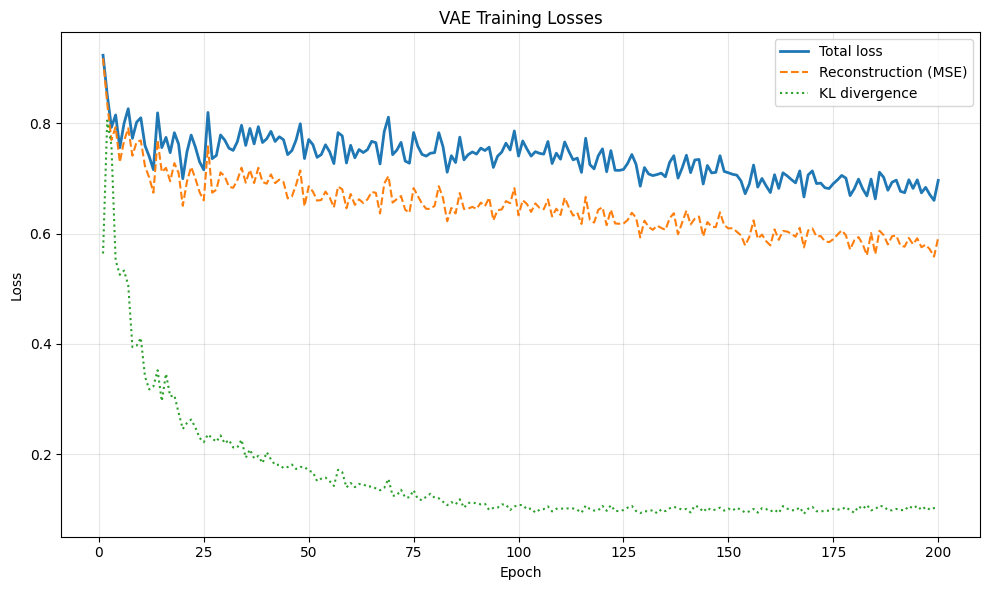

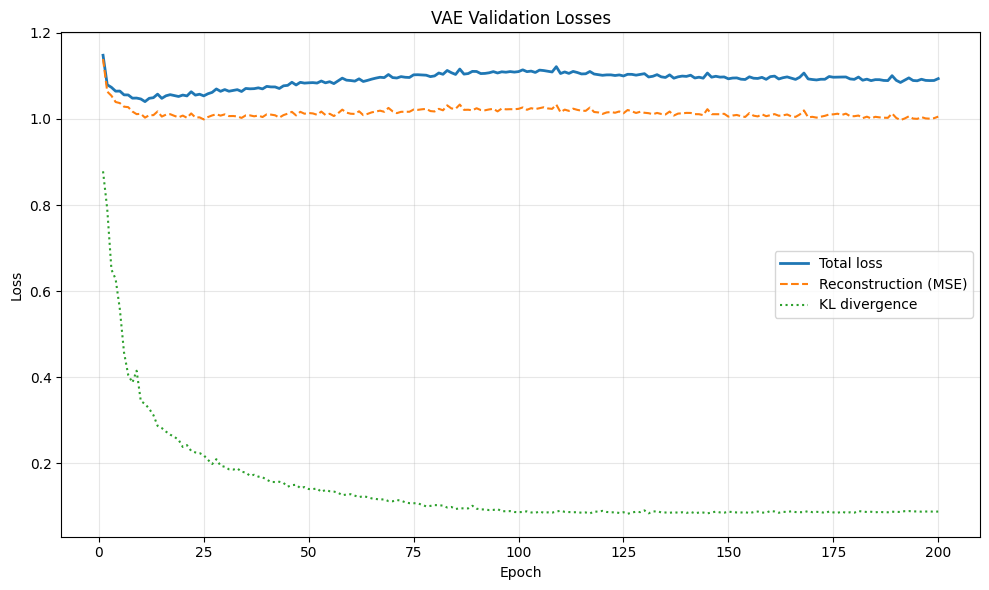

In [ ]:
plot_model_metrics(my_vae, "VAE")

## t-SNE

In [24]:
X_all = scaler.transform(data_final)
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)

In [ ]:
all_dataset = TensorDataset(X_all_tensor, torch.zeros(len(X_all)))
all_loader  = DataLoader(all_dataset, batch_size=256, shuffle=False)

Get latent means for all samples

In [ ]:
my_vae = VAE_Extended(
    input_dim=X_train.shape[1],
    latent_dim=64,
    lr=1e-4,
    epochs=200,
    annealing_epochs=100
)

# Load weights
my_vae.load_state_dict(torch.load("02_models/deep/trained_models/vae_baseline.pth", map_location=device))
my_vae.to(device)

VAE_Extended(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=6000, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=128, bias=True)
      (3): ReLU()
    )
    (mu): Linear(in_features=128, out_features=64, bias=True)
    (logvar): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=6000, bias=True)
    )
  )
  (criterion): MSELoss()
)

In [ ]:
mus_all = eval_model(my_vae, all_loader, device, use_domain=False)

Global t-SNE

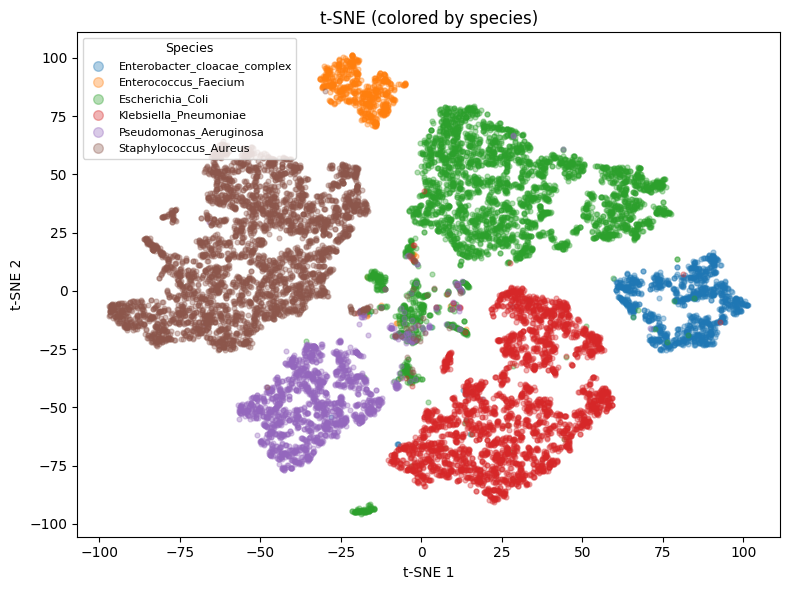

In [ ]:
tsne_df = compute_tsne_df(mus_all, label_final, meta_final)
plot_tsne_global(tsne_df, False)

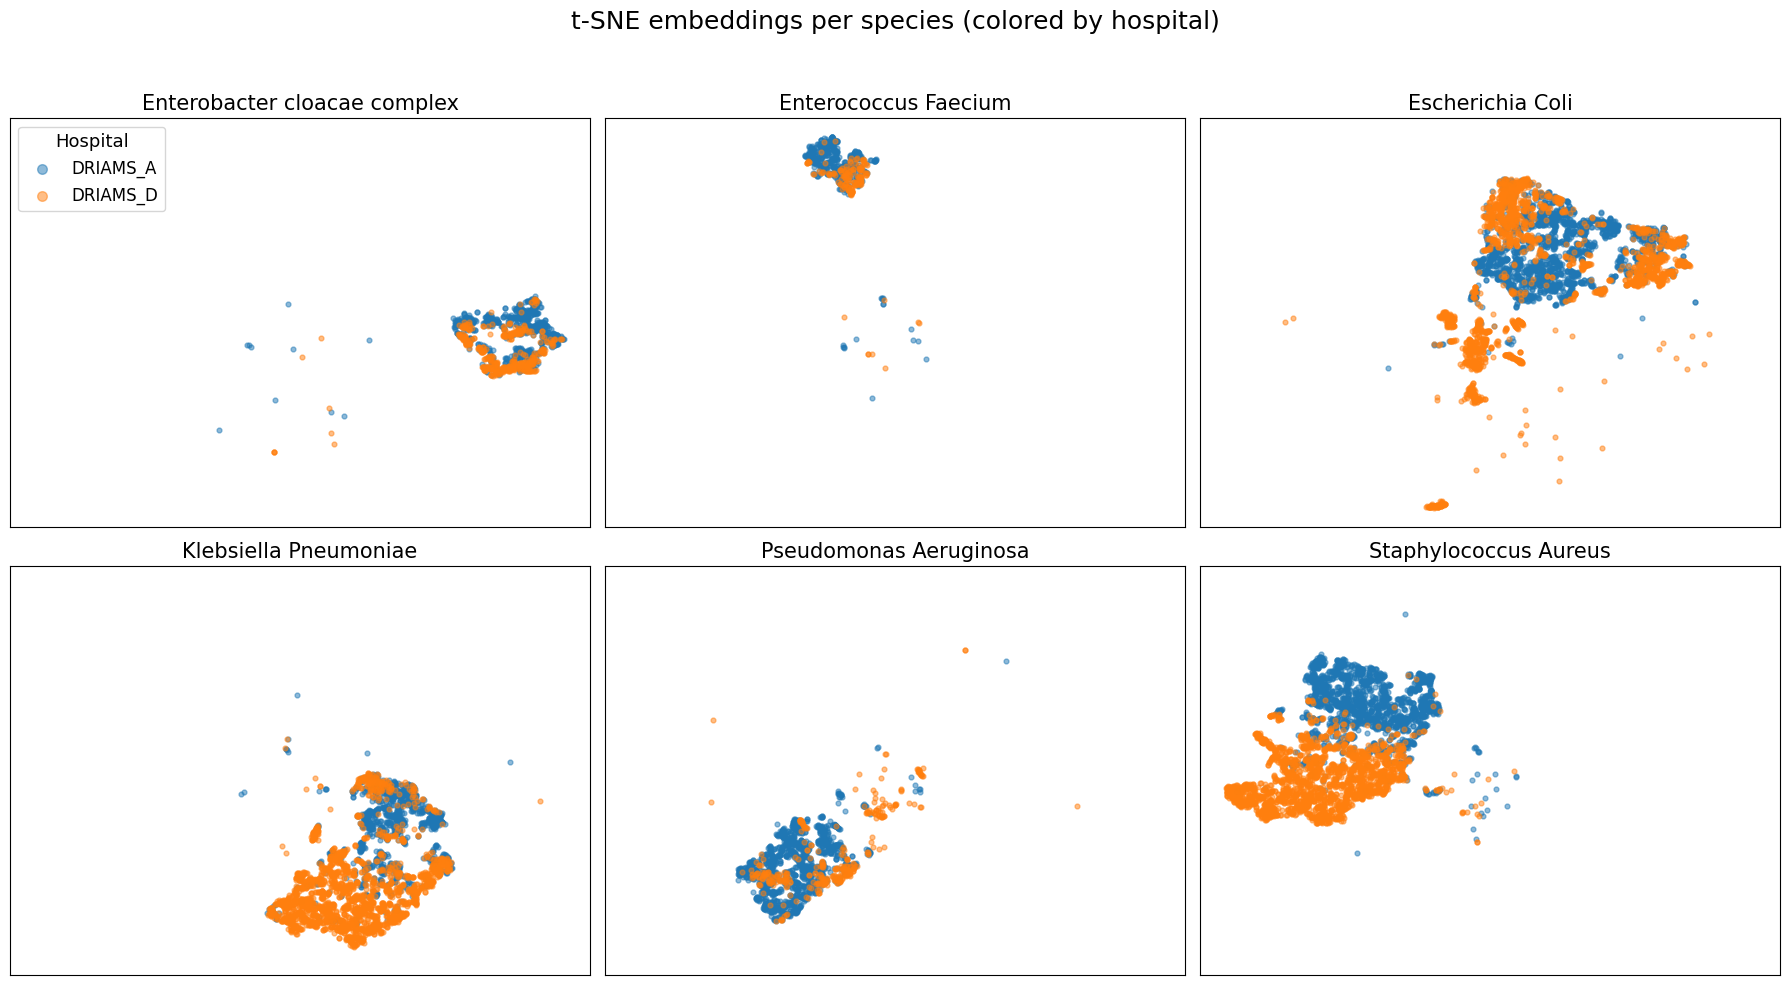

In [ ]:
plot_tsne_global(tsne_df, per_species=True)

t-SNE for each species separately

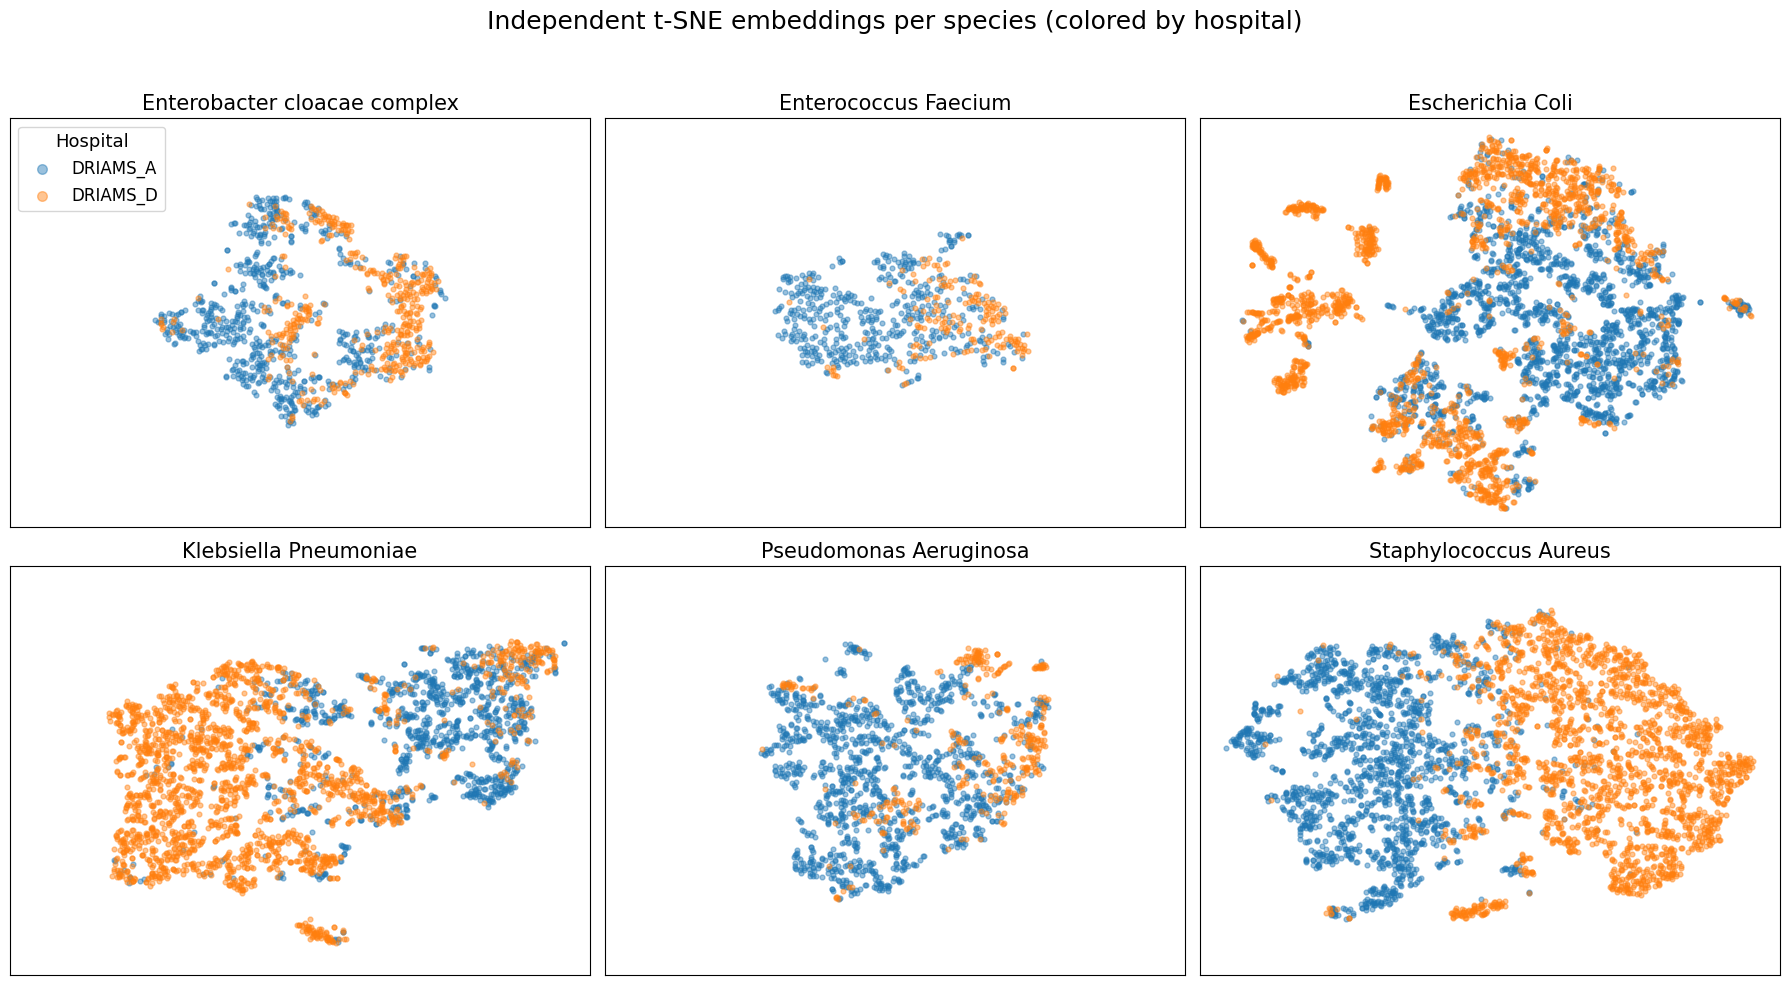

In [ ]:
df_all, tsne_results = compute_tsne_per_species(mus_all, label_final, meta_final)
plot_tsne_species(df_all, tsne_results)